# Week 9 — Diffusion models from scratch

 Estimate the score function empirically → show
why it doesn't scale → introduce denoising score matching as the fix →
build the forward process → train a denoiser on the Dino dataset →
sample with DDPM (stochastic) and DDIM (deterministic) → scale to images.


In Week 4, the gradient field $\nabla_x f(x)$ told us about a network's
sensitivity to inputs. This week, we study a different gradient field:
**the score function** $\nabla_x \log p(x)$, which points toward
high-density regions of the *data distribution*.

Diffusion models learn this score by training a denoiser — a network that
predicts the noise added to data. The trained denoiser implicitly knows
the score at every noise level, and we can use it to generate new samples
by starting from pure noise and following the score back to the data.

### Two samplers

- **DDPM** (Ho et al., 2020): stochastic reverse process. Each step adds
  fresh noise. Requires ~1000 steps.
- **DDIM** (Song et al., 2021): deterministic reverse process. Same trained
  model, no retraining. Can use 10–50 steps. This is what's used in
  practice.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cuda


## Data — the Dino dataset

A 2D toy dataset shaped like a dinosaur. We use it because:
- 2D allows direct visualization of the score field and sampling trajectories
- The complex shape (multiple modes, thin structures) challenges the model
- It's a standard benchmark for 2D diffusion demos

Original dino points: (142, 2)


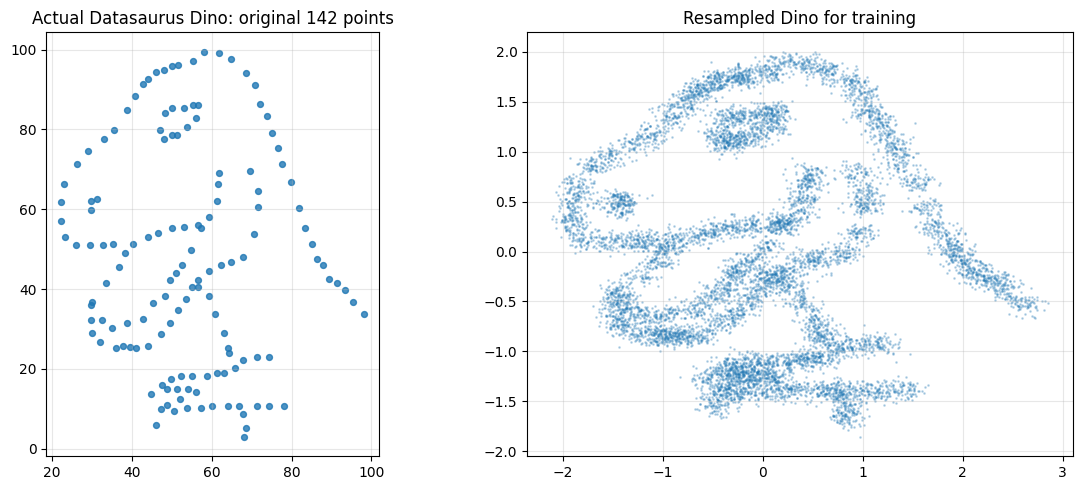

Tensor shape: torch.Size([10000, 2])
Device: cuda:0


In [ ]:
import urllib.request
import csv
import io

import numpy as np
import torch
import matplotlib.pyplot as plt


def load_actual_datasaurus_dino(
    n_samples=10000,
    jitter_scale=1.5,
    normalize=True,
    seed=0,
):
    """
    Load the actual Datasaurus 'dino' coordinates, then optionally resample
    and jitter them for ML training.
    """

    url = (
        "https://raw.githubusercontent.com/"
        "jumpingrivers/datasauRus/main/"
        "inst/extdata/DatasaurusDozen-Long.tsv"
    )

    rng = np.random.default_rng(seed)

    with urllib.request.urlopen(url) as response:
        raw = response.read().decode("utf-8")

    reader = csv.DictReader(io.StringIO(raw), delimiter="\t")

    points = []
    for row in reader:
        if row["dataset"].strip() == "dino":
            points.append([float(row["x"]), float(row["y"])])

    base_data = np.asarray(points, dtype=np.float32)

    print("Original dino points:", base_data.shape)

    # Resample from the actual 142 dino points
    idx = rng.choice(len(base_data), size=n_samples, replace=True)
    data = base_data[idx].copy()

    # Use very small jitter if you want density; 0.0 gives exact original points
    if jitter_scale is not None and jitter_scale > 0:
        data += rng.normal(0.0, jitter_scale, size=data.shape).astype(np.float32)

    if normalize:
        data = (data - data.mean(axis=0, keepdims=True)) / (
            data.std(axis=0, keepdims=True) + 1e-8
        )

    return data.astype(np.float32), base_data.astype(np.float32)


# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_np, base_dino_np = load_actual_datasaurus_dino(
    n_samples=10000,
    jitter_scale=1.5,
    normalize=True,
    seed=0,
)

data_tensor = torch.tensor(data_np, dtype=torch.float32).to(device)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original 142 points, unnormalized
axes[0].scatter(base_dino_np[:, 0], base_dino_np[:, 1], s=18, alpha=0.8)
axes[0].set_title("Actual Datasaurus Dino: original 142 points")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

# Resampled / normalized training version
axes[1].scatter(data_np[:, 0], data_np[:, 1], s=1, alpha=0.25)
axes[1].set_title("Resampled Dino for training")
axes[1].set_aspect("equal")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Tensor shape:", data_tensor.shape)
print("Device:", data_tensor.device)

## Part 1 — The score function: $\nabla_x \log p(x)$

### What is the score?

The **score function** of a distribution $p(x)$ is the gradient of its
log-density:

$$
s(x) = \nabla_x \log p(x)
$$

At any point $x$, the score points in the direction of increasing
log-probability — toward regions where the data is denser. It's a vector
field over the entire input space.

### Why we care

If we know the score everywhere, we can generate samples by starting from
random noise and following the score "uphill" to high-density regions.
This is the core idea behind score-based generative models.

### Estimating the score empirically

For a 2D dataset, we can estimate the density $p(x)$ using kernel density
estimation (KDE) and then differentiate to get the score. This works in
2D but fails in high dimensions (curse of dimensionality — KDE needs
exponentially many samples). This is why we'll need denoising score
matching (Part 2).

In [ ]:
from scipy.stats import gaussian_kde

# Fit KDE to the data
kde = gaussian_kde(data_np.T, bw_method=0.15)

# Evaluate on a grid
n_grid = 50
x_range = np.linspace(data_np[:, 0].min() - 0.5, data_np[:, 0].max() + 0.5, n_grid)
y_range = np.linspace(data_np[:, 1].min() - 0.5, data_np[:, 1].max() + 0.5, n_grid)
XX, YY = np.meshgrid(x_range, y_range)
grid_points = np.column_stack([XX.ravel(), YY.ravel()])

# TODO: Calculate log-density
# Hint: Use np.log(kde(...) + 1e-10)
log_density = np.zeros(XX.shape)

# TODO: Calculate Score: ∇_x log p(x) via finite differences
# Hint: Use np.gradient with log_density and step sizes dx, dy
dx = x_range[1] - x_range[0]
dy = y_range[1] - y_range[0]
score_x = np.zeros(XX.shape)
score_y = np.zeros(XX.shape)

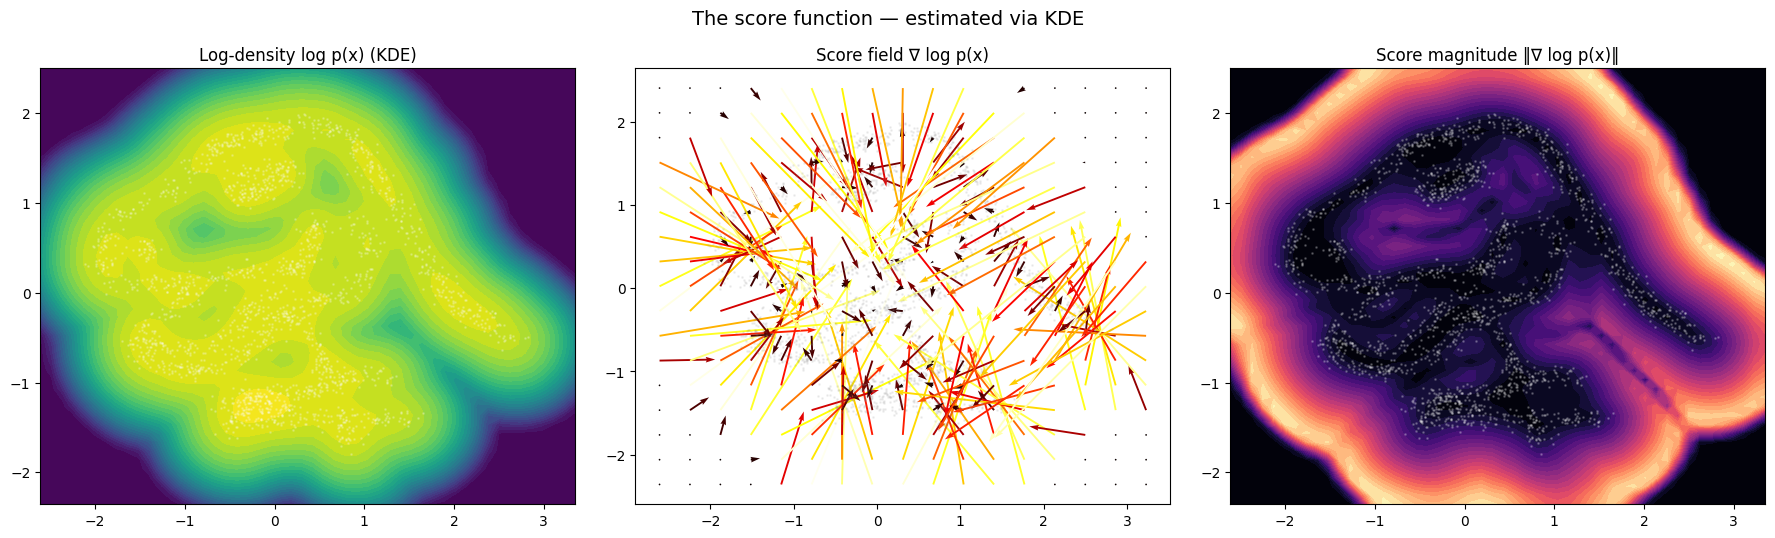

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: log-density
ax = axes[0]
ax.contourf(XX, YY, log_density, levels=30, cmap='viridis')
ax.scatter(data_np[:2000, 0], data_np[:2000, 1], s=1, alpha=0.2, c='white')
ax.set_title('Log-density log p(x) (KDE)')
ax.set_aspect('equal')

# Middle: score field (subsample for readability)
ax = axes[1]
skip = 3
ax.quiver(XX[::skip, ::skip], YY[::skip, ::skip],
          score_x[::skip, ::skip], score_y[::skip, ::skip],
          np.sqrt(score_x[::skip, ::skip]**2 + score_y[::skip, ::skip]**2),
          cmap='hot', scale=80)
ax.scatter(data_np[:2000, 0], data_np[:2000, 1], s=1, alpha=0.1, c='gray')
ax.set_title('Score field ∇ log p(x)')
ax.set_aspect('equal')

# Right: score magnitude
ax = axes[2]
score_mag = np.sqrt(score_x**2 + score_y**2)
ax.contourf(XX, YY, score_mag, levels=30, cmap='magma')
ax.scatter(data_np[:2000, 0], data_np[:2000, 1], s=1, alpha=0.2, c='white')
ax.set_title('Score magnitude ‖∇ log p(x)‖')
ax.set_aspect('equal')

plt.suptitle('The score function — estimated via KDE', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### What the score field shows

The arrows point toward high-density regions. Near the data (inside the
dino shape), the score is small — you're already at high density. Far from
the data, the score is large and points toward the nearest part of the
dino.

**This is the gradient field applied to the data distribution
instead of a classifier.** In Week 4, $\nabla_x f$ pointed in the
direction of increasing classifier output. Here, $\nabla_x \log p$ points
in the direction of increasing data density.

### Why KDE doesn't scale

KDE requires $O(N)$ distance computations per query point, where $N$ is
the number of data points. In high dimensions ($d > 10$), the bandwidth
selection becomes unreliable and the density estimate degrades
exponentially. We need a scalable alternative — **denoising score
matching**.

## Part 2 — Denoising score matching

### (Vincent, 2011)

Instead of estimating $\nabla_x \log p(x)$ directly, add noise to the
data and train a network to remove it. A network that can optimally
denoise has implicitly learned the score.
### The equivalence: denoising gives the score

Add Gaussian noise:

$$
\tilde{x} = x + \sigma \epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I).
$$

The noisy distribution is

$$
q_\sigma(\tilde{x})
=
\int p(x)\mathcal{N}(\tilde{x}; x, \sigma^2 I)\,dx.
$$

Now comes the key identity, often called **Tweedie's formula**:

$$
\mathbb{E}[x \mid \tilde{x}]
=
\tilde{x}
+
\sigma^2 \nabla_{\tilde{x}} \log q_\sigma(\tilde{x}).
$$

Rearranging gives

$$
\nabla_{\tilde{x}} \log q_\sigma(\tilde{x})
=
\frac{\mathbb{E}[x \mid \tilde{x}] - \tilde{x}}{\sigma^2}.
$$

So if the optimal denoiser is

$$
D^*(\tilde{x}) = \mathbb{E}[x \mid \tilde{x}],
$$

then

$$
\nabla_{\tilde{x}} \log q_\sigma(\tilde{x})
=
\frac{D^*(\tilde{x}) - \tilde{x}}{\sigma^2}.
$$

In words:  
**the direction from the noisy point back to the denoised prediction is the score direction.**

Equivalently, since

$$
\tilde{x} = x + \sigma \epsilon,
$$

we have

$$
x = \tilde{x} - \sigma \epsilon.
$$

So predicting the clean data $x$, predicting the noise $\epsilon$, and
predicting the score are all equivalent up to simple transformations.

If we train a network $\epsilon_\theta(\tilde{x}, \sigma)$ to minimize

$$
\|\epsilon_\theta(\tilde{x}, \sigma) - \epsilon\|^2,
$$

then

$$
\nabla_{\tilde{x}} \log q_\sigma(\tilde{x})
\approx
-\frac{\epsilon_\theta(\tilde{x}, \sigma)}{\sigma}.
$$




## Part 3 — The forward process

The forward (noising) process gradually adds Gaussian noise to the data
over $T$ timesteps:

$$
q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar\alpha_t}\, x_0, (1-\bar\alpha_t) I)
$$

where $\bar\alpha_t = \prod_{s=1}^t \alpha_s$ and $\alpha_t = 1 - \beta_t$
with $\beta_t$ following a noise schedule.

At $t = 0$: $x_0$ is the clean data.
At $t = T$: $x_T \approx \mathcal{N}(0, I)$ — pure noise.

The reparameterization: $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon$
where $\epsilon \sim \mathcal{N}(0, I)$.

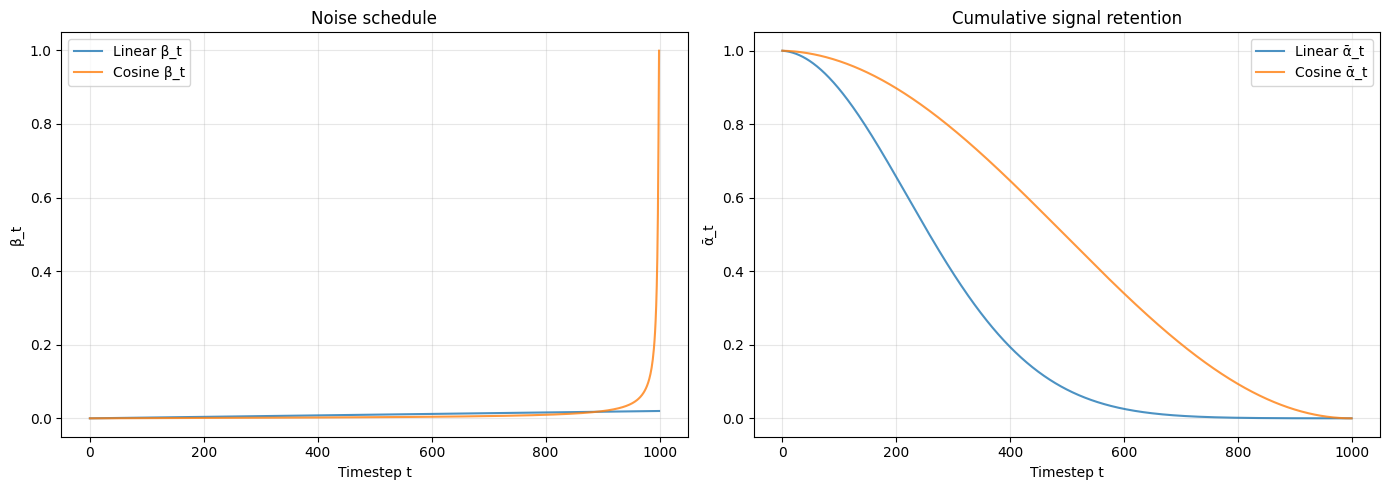

In [ ]:
def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    '''TODO: Implement linear noise schedule (DDPM default).'''
    betas = torch.zeros(T)
    alphas = torch.zeros(T)
    alpha_bars = torch.zeros(T)
    return betas, alphas, alpha_bars

def cosine_schedule(T, s=0.008):
    '''TODO: Implement cosine noise schedule (improved DDPM).'''
    betas = torch.zeros(T)
    alphas = torch.zeros(T)
    alpha_bars = torch.zeros(T)
    return betas, alphas, alpha_bars

T = 1000
betas, alphas, alpha_bars = linear_schedule(T)
betas_cos, alphas_cos, alpha_bars_cos = cosine_schedule(T)

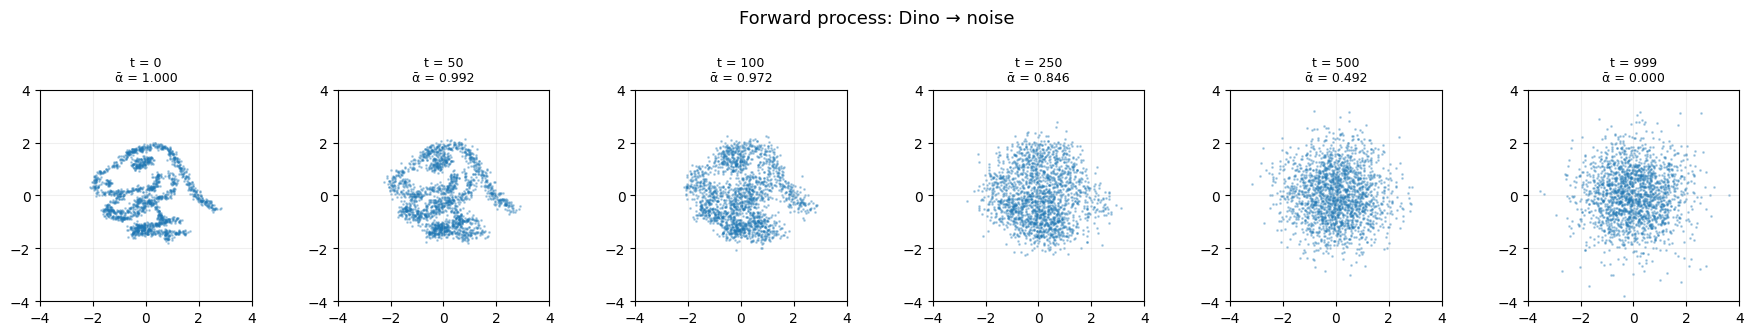

In [ ]:
betas, alphas, alpha_bars = cosine_schedule(T)
alpha_bars_dev = alpha_bars.to(device)

def forward_process(x_0, t, alpha_bars):
    '''TODO: Add noise to x_0 at timestep t. Returns x_t and the noise epsilon.'''
    # Hint: x_t = sqrt(a_bar) * x_0 + sqrt(1 - a_bar) * epsilon
    x_t = x_0
    epsilon = torch.zeros_like(x_0)
    return x_t, epsilon

## Part 4 — Train a noise predictor

The training loop:

1. Sample $x_0$ from the data.
2. Sample $t \sim \text{Uniform}(0, T-1)$.
3. Sample $\epsilon \sim \mathcal{N}(0, I)$.
4. Compute $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon$.
5. Predict $\hat\epsilon = \epsilon_\theta(x_t, t)$.
6. Loss $= \|\hat\epsilon - \epsilon\|^2$.

The network takes $(x_t, t)$ as input and outputs a noise prediction of
the same dimensionality as $x_t$. For 2D data, this is a small MLP.
The timestep $t$ is encoded via sinusoidal embeddings (same idea as
positional encoding in transformers).

In [ ]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # TODO: Implement sinusoidal positional encoding for timestep t
        return torch.zeros(t.shape[0], self.dim).to(t.device)

class NoisePredictor(nn.Module):
    def __init__(self, data_dim=2, hidden_dim=256, time_dim=64):
        super().__init__()
        self.time_embed = SinusoidalEmbedding(time_dim)
        # TODO: Define a multi-layer MLP
        self.net = nn.Identity()

    def forward(self, x_t, t):
        # TODO: Concatenate x_t and time embedding, then pass through net
        return x_t

  step  2000: loss = 0.450442
  step  4000: loss = 0.474350
  step  6000: loss = 0.466167
  step  8000: loss = 0.470868
  step 10000: loss = 0.424607
  step 12000: loss = 0.447782
  step 14000: loss = 0.483336
  step 16000: loss = 0.462170
  step 18000: loss = 0.441772
  step 20000: loss = 0.438071
  step 22000: loss = 0.454235
  step 24000: loss = 0.458210
  step 26000: loss = 0.446248
  step 28000: loss = 0.454017
  step 30000: loss = 0.455146
  step 32000: loss = 0.426936
  step 34000: loss = 0.458154
  step 36000: loss = 0.474999
  step 38000: loss = 0.467578
  step 40000: loss = 0.450166
  step 42000: loss = 0.449591
  step 44000: loss = 0.429359
  step 46000: loss = 0.416025
  step 48000: loss = 0.460638
  step 50000: loss = 0.440290


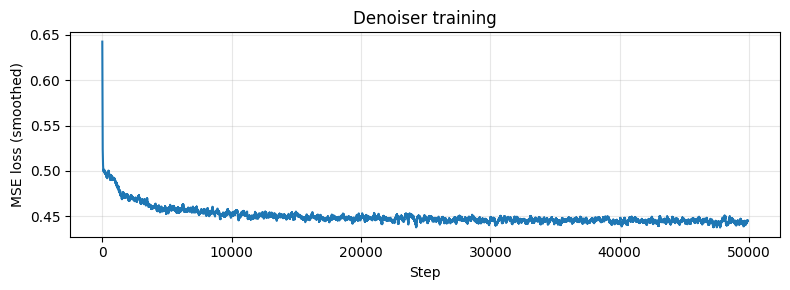

In [ ]:
# Training configuration
model = NoisePredictor(data_dim=2, hidden_dim=256, time_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
n_steps = 50000
batch_size = 1024
losses = []

for step in range(1, n_steps + 1):
    # TODO: 1. Sample x_0 from data_tensor

    # TODO: 2. Sample random t for each batch element

    # TODO: 3. Sample Gaussian noise epsilon

    # TODO: 4. Compute noisy x_t (Forward Process)

    # TODO: 5. Predict noise using the model
    eps_pred = torch.zeros(1)

    # TODO: 6. Compute MSE Loss between predicted and actual noise
    loss = torch.tensor(0.0)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

## Part 5 — DDPM sampling (stochastic)

The DDPM reverse process (Ho et al., 2020):

$$
x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(x_t, t)\right) + \sigma_t z
$$

where $z \sim \mathcal{N}(0, I)$ and $\sigma_t = \sqrt{\beta_t}$.

Each step:
1. Predict the noise $\epsilon_\theta(x_t, t)$.
2. Compute the "denoised estimate" of $x_0$.
3. Add fresh noise (except at $t=1$).

This requires $T = 1000$ steps (one per timestep in the forward process).

### DDPM reverse process: one denoising step

At timestep $t$, we have a noisy sample $x_t$.

The neural network predicts the noise inside $x_t$:

$$
\epsilon_\theta(x_t, t)
\approx
\epsilon.
$$

From this predicted noise, we estimate the clean sample:

$$
\hat{x}_0
=
\frac{x_t - \sqrt{1-\bar{\alpha}_t}\epsilon_\theta(x_t,t)}
{\sqrt{\bar{\alpha}_t}}.
$$

But DDPM does **not** directly set

$$
x_{t-1} = \hat{x}_0.
$$

That would remove too much noise at once. Instead, DDPM uses $\hat{x}_0$ to compute a slightly denoised sample and then adds back a controlled amount of Gaussian noise.

Conceptually:

```text
current noisy sample      predict noise      estimate clean data      add controlled noise      next sample

        x_t        --->   ε_θ(x_t,t)   --->       x̂_0          --->      + σ_t z       --->     x_{t-1}

In [ ]:
@torch.no_grad()
def ddpm_sample(model, n_samples, data_dim=2, T=1000, alpha_bars=None, betas=None, alphas=None):
    model.eval()
    x = torch.randn(n_samples, data_dim, device=device)

    for t in reversed(range(T)):
        # TODO: Implement the DDPM reverse step
        # 1. Predict noise
        # 2. Estimate mean using Tweedie's formula
        # 3. Add noise (if t > 0)
        pass

    model.train()
    return x, []

Sampling with DDPM (1000 steps)...
Done.


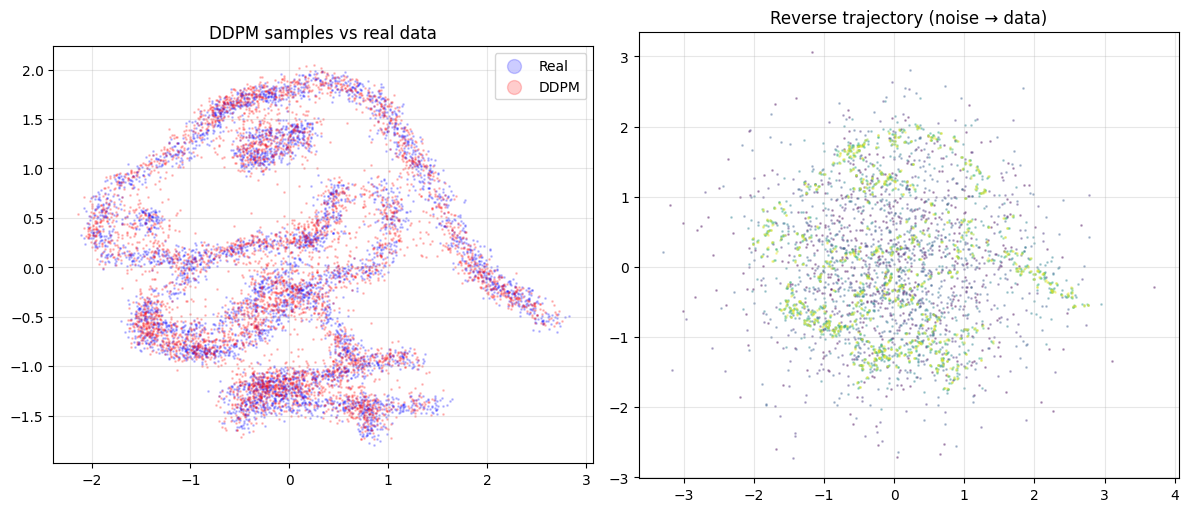

In [ ]:
# --- Visualize DDPM samples and trajectory -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: final samples vs real data
ax = axes[0]
ax.scatter(data_np[:5000, 0], data_np[:5000, 1], s=1, alpha=0.2, label='Real', c='blue')
ax.scatter(samples_ddpm[:, 0].cpu(), samples_ddpm[:, 1].cpu(), s=1, alpha=0.2,
           label='DDPM', c='red')
ax.set_title('DDPM samples vs real data')
ax.legend(markerscale=10); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# Right: reverse trajectory snapshots
ax = axes[1]
n_show = min(8, len(traj_ddpm))
step_indices = np.linspace(0, len(traj_ddpm)-1, n_show, dtype=int)
colors = plt.cm.viridis(np.linspace(0, 1, n_show))

for i, idx in enumerate(step_indices):
    samples = traj_ddpm[idx][:500]
    ax.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.3, color=colors[i])

ax.set_title('Reverse trajectory (noise → data)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 6 — DDIM sampling (deterministic)

DDIM (Song et al., 2021) uses the same trained model but a different
sampling procedure:

$$
x_{t-1} = \sqrt{\bar\alpha_{t-1}} \left(\frac{x_t - \sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t, t)}{\sqrt{\bar\alpha_t}}\right) + \sqrt{1 - \bar\alpha_{t-1}} \cdot \epsilon_\theta(x_t, t)
$$

### Key differences from DDPM

1. **Deterministic**: no random noise added. Same starting noise → same
   output. This enables interpolation in latent space.
2. **Fewer steps**: DDIM can skip timesteps. Instead of $t = 999, 998, \ldots, 0$,
   use a subsequence like $t = 999, 949, 899, \ldots, 0$ (every 50th step).
   This gives 20 steps instead of 1000, with minimal quality loss.
3. **Same model**: no retraining needed. DDIM is a different *sampler*
   for the same trained *denoiser*.

The DDPM forward process is a *stochastic* differential equation. DDIM
corresponds to the **probability flow ODE** — a deterministic ODE that
produces the same marginal distributions $p_t(x)$ at each timestep. Both
paths connect the same endpoints (data distribution ↔ Gaussian), just via
different trajectories.

### DDIM as larger deterministic jumps

The important difference is that DDIM does not have to move from $x_t$ to the immediately previous timestep $x_{t-1}$.

Instead, we can choose a smaller timestep $s < t$ and jump directly from $x_t$ to $x_s$.

For example, DDPM usually follows all timesteps:

$$
x_{999} \rightarrow x_{998} \rightarrow x_{997} \rightarrow \cdots \rightarrow x_1 \rightarrow x_0.
$$

DDIM can use a shorter sequence:

$$
x_{999} \rightarrow x_{949} \rightarrow x_{899} \rightarrow \cdots \rightarrow x_{49} \rightarrow x_0.
$$

Each DDIM step still uses the same trained network. First, we predict the noise:

$$
\epsilon_\theta(x_t, t).
$$

Then we estimate the clean sample:

$$
\hat{x}_0
=
\frac{x_t - \sqrt{1-\bar\alpha_t}\epsilon_\theta(x_t,t)}
{\sqrt{\bar\alpha_t}}.
$$

Now instead of adding fresh random noise as in DDPM, DDIM uses this estimated clean sample and the predicted noise direction to construct the sample at a lower noise level $s$:

$$
x_s
=
\sqrt{\bar\alpha_s}\hat{x}_0
+
\sqrt{1-\bar\alpha_s}\epsilon_\theta(x_t,t).
$$

So the process is:

$$
x_t
\quad
\longrightarrow
\quad
\epsilon_\theta(x_t,t)
\quad
\longrightarrow
\quad
\hat{x}_0
\quad
\longrightarrow
\quad
x_s.
$$

In words:

```text
current noisy sample      predict noise      estimate clean sample      jump to lower noise level

        x_t        --->   ε_θ(x_t,t)   --->        x̂_0          --->            x_s

In [ ]:
@torch.no_grad()
def ddim_sample(model, n_samples, data_dim=2, T=1000, alpha_bars=None, n_steps=50):
    model.eval()
    # TODO: Implement DDIM deterministic sampling
    # 1. Subsample timesteps
    # 2. For each step: predict x_0, then jump to next lower noise level
    return torch.randn(n_samples, data_dim, device=device), []

DDIM sampling at different step counts:
    10 steps: done
    25 steps: done
    50 steps: done
   100 steps: done
   200 steps: done


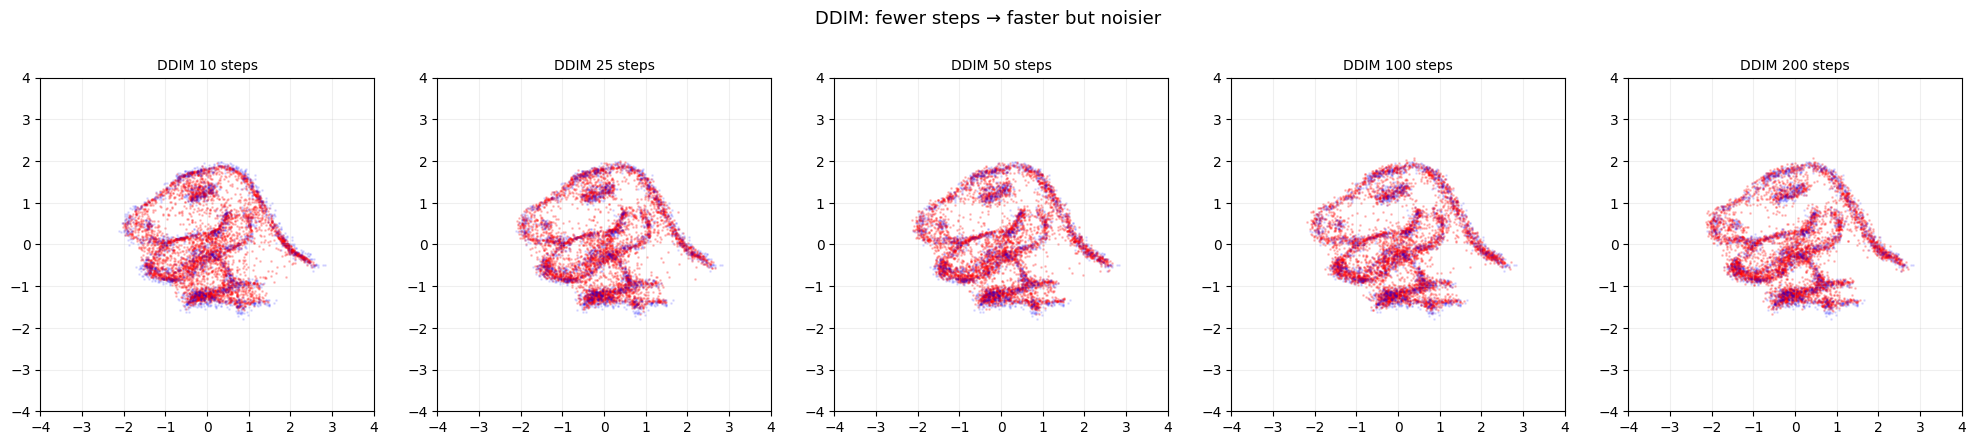

In [ ]:
# --- Visualize DDIM at different step counts ---------------------------------
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (n_steps, samples) in zip(axes, ddim_results.items()):
    ax.scatter(samples[:, 0].cpu(), samples[:, 1].cpu(), s=1, alpha=0.2, c='red')
    ax.scatter(data_np[:2000, 0], data_np[:2000, 1], s=1, alpha=0.1, c='blue')
    ax.set_title(f'DDIM {n_steps} steps', fontsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

plt.suptitle('DDIM: fewer steps → faster but noisier', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

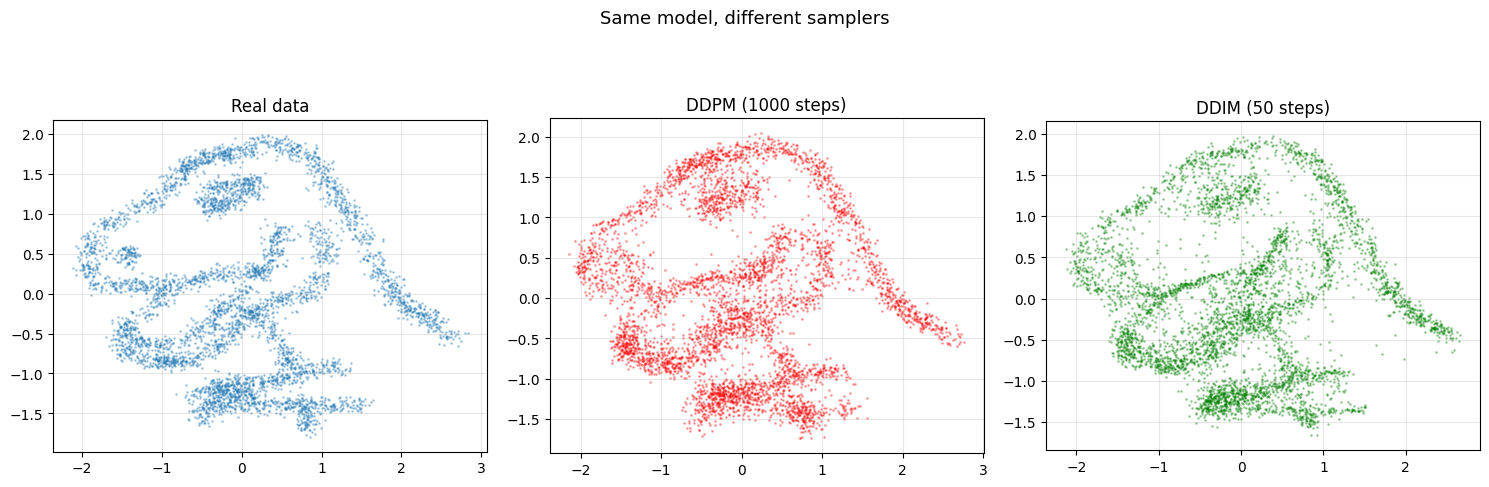

DDPM: 1000 model evaluations
DDIM (50 steps): 50 model evaluations — 20× faster


In [ ]:
# --- DDPM (1000 steps) vs DDIM (50 steps) side by side ----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.scatter(data_np[:5000, 0], data_np[:5000, 1], s=1, alpha=0.3)
ax.set_title('Real data'); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(samples_ddpm[:, 0].cpu(), samples_ddpm[:, 1].cpu(), s=1, alpha=0.3, c='red')
ax.set_title(f'DDPM (1000 steps)'); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.scatter(ddim_results[50][:, 0].cpu(), ddim_results[50][:, 1].cpu(),
           s=1, alpha=0.3, c='green')
ax.set_title(f'DDIM (50 steps)'); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.suptitle('Same model, different samplers', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("DDPM: 1000 model evaluations")
print("DDIM (50 steps): 50 model evaluations — 20× faster")

## Part 7 — The learned score field

Now that we have a trained denoiser, we can visualize the learned score
field at different noise levels. Recall:

$$
\nabla_x \log p_t(x) \approx -\frac{\epsilon_\theta(x, t)}{\sqrt{1-\bar\alpha_t}}
$$

At high noise ($t$ large): the score points toward the global data center.
At low noise ($t$ small): the score points toward local data structures.

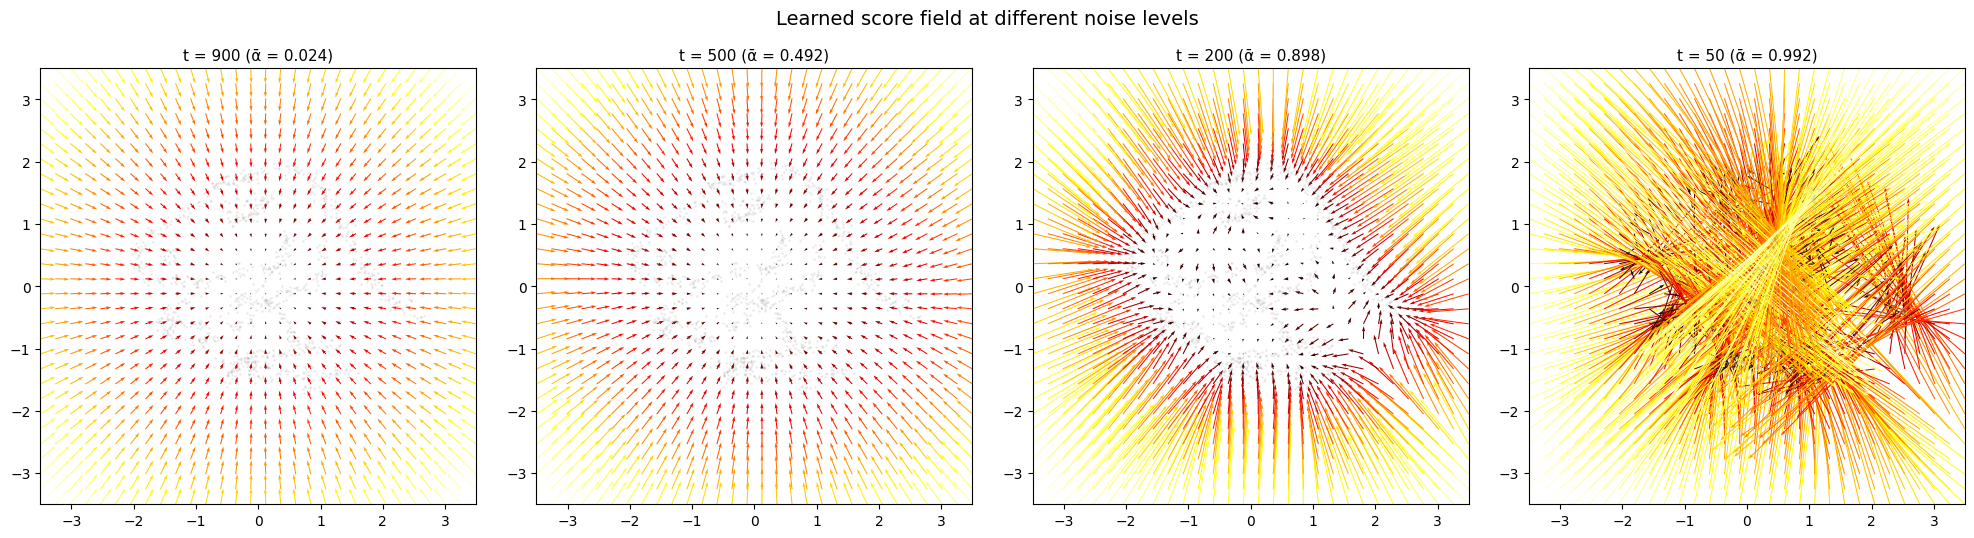

In [ ]:
# TODO: Visualize the learned score field
# Hint: Score = -eps_pred / sqrt(1 - alpha_bar_t)
# Reuse the grid plotting logic from Part 1

### What the score fields show

**High noise ($t = 900$)**: the score is smooth and points toward the
global center. At this noise level, all fine structure is destroyed —
the denoiser sees a blurry blob and points everything inward.

**Medium noise ($t = 500$)**: the score begins to show structure — it
points toward the major features of the dino (body, head, tail).

**Low noise ($t = 50$)**: the score is highly structured, pointing toward
the precise data manifold. This is where the fine details (legs, tail tip)
are resolved.

**The multi-scale hierarchy**: the diffusion process denoises from coarse
to fine. High noise levels establish global structure; low noise levels
add detail. This is analogous to how image generation works — the overall
composition appears first, then textures and details appear at later
(lower-noise) steps.

## Final observations

**Q1.** The score function $\nabla_x \log p(x)$ and the Week 4 gradient
$\nabla_x f(x)$ are both vector fields over input space. How are they
different?

> The classifier gradient $\nabla_x f$ points toward increasing classifier
> output (adversarial direction). The score $\nabla_x \log p$ points
> toward increasing data density (toward the data manifold). One is about
> a learned function; the other is about the data distribution itself.

**Q2.** Why does denoising score matching work? Why does predicting noise
give you the score?

> The optimal noise predictor satisfies
> $\epsilon^*(x_t, t) = -\sigma_t \nabla_x \log p_t(x_t)$. This is
> because removing noise is equivalent to following the score — both
> point from the noisy observation toward the clean data.

**Q3.** DDIM uses the same model as DDPM but gives different (and fewer)
sampling steps. How is this possible?

> DDPM defines a stochastic reverse process (with added noise at each
> step). DDIM defines a deterministic reverse process (the probability
> flow ODE) that produces the same marginal distributions. Both use the
> trained $\epsilon_\theta$ to compute the denoising direction, but DDIM
> skips the noise injection, making each step larger and more efficient.

**Q4.** The score field at high noise is smooth; at low noise it's
structured. Why does this matter for sampling?

> Sampling proceeds from high noise to low noise. At high noise, the
> smooth score provides a stable, convergent signal — all paths head
> toward the data. At low noise, the structured score resolves fine
> details. This coarse-to-fine hierarchy is why diffusion generates
> globally coherent samples with local detail.

**Q5.** Cosine vs linear noise schedule — when does the choice matter?

> The cosine schedule spends more timesteps at low noise levels (where
> details are resolved) and fewer at high noise (where the data is just
> a blob). This improves image quality because the model gets more
> training signal for the detail-critical low-noise regime. For 2D data
> the difference is minimal; for images it's significant.